# STAIX Challenge 2026

In [3]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

## Data cleaning

Begin by loading the tabular data from the training dataset.

In [4]:
from src.data_loader import find_data_dir

# Get data directory
root = find_data_dir()


#  Get base and data directories
data_dir = root / "data"
train_dir = data_dir / "train"
test_dir = data_dir / "val"

# Load tabular data as dataframes
X_raw = pd.read_table(train_dir / "covariates.csv", sep = ",")
y_raw = pd.read_table(train_dir / "dose_sys_train.csv", sep = ",")

# Dimensions
print(f"# datapoints in training data : {X_raw.shape[0]}")
print(f"# raw features                : {X_raw.shape[1]}")


FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\eddyk\\cloned_repos\\staix26_seasthemoment\\notebooks\\..\\data\\data\\train\\covariates.csv'

In [4]:
y_raw.shape

(31416, 4)

Load the image data as well. Since we are working with heatmaps, we can read each PNG as gray-scale image so that we don't split into RGB.

Note: how to consider only inside the state border?

In [1]:
from PIL import Image

# Get image directory and files
im_dir = train_dir / "images" / "mat_density"
im_names = os.listdir(im_dir) # Use later to match up with tabular data
im_paths = [im_dir / png for png in im_names]

# Load each png
imgs = []
for png in im_paths:
  img = Image.open(png).convert("L") # grayscale, single-channel
  arr = np.asarray(img)
  imgs.append(arr)

# Convert to array
imgs = np.asarray(imgs)
print(f"# of images      : {imgs.shape[0]}")
print(f"Image dimensions : {imgs.shape[1:]}")

NameError: name 'train_dir' is not defined

Let's clean up our datafames and examine the NA content of the tabular data.

/usr/local/lib/python3.12/dist-packages/missingno/missingno.py:61: UserWarning: Plotting a sparkline on an existing axis is not currently supported. To remove this warning, set sparkline=False.
  warnings.warn(


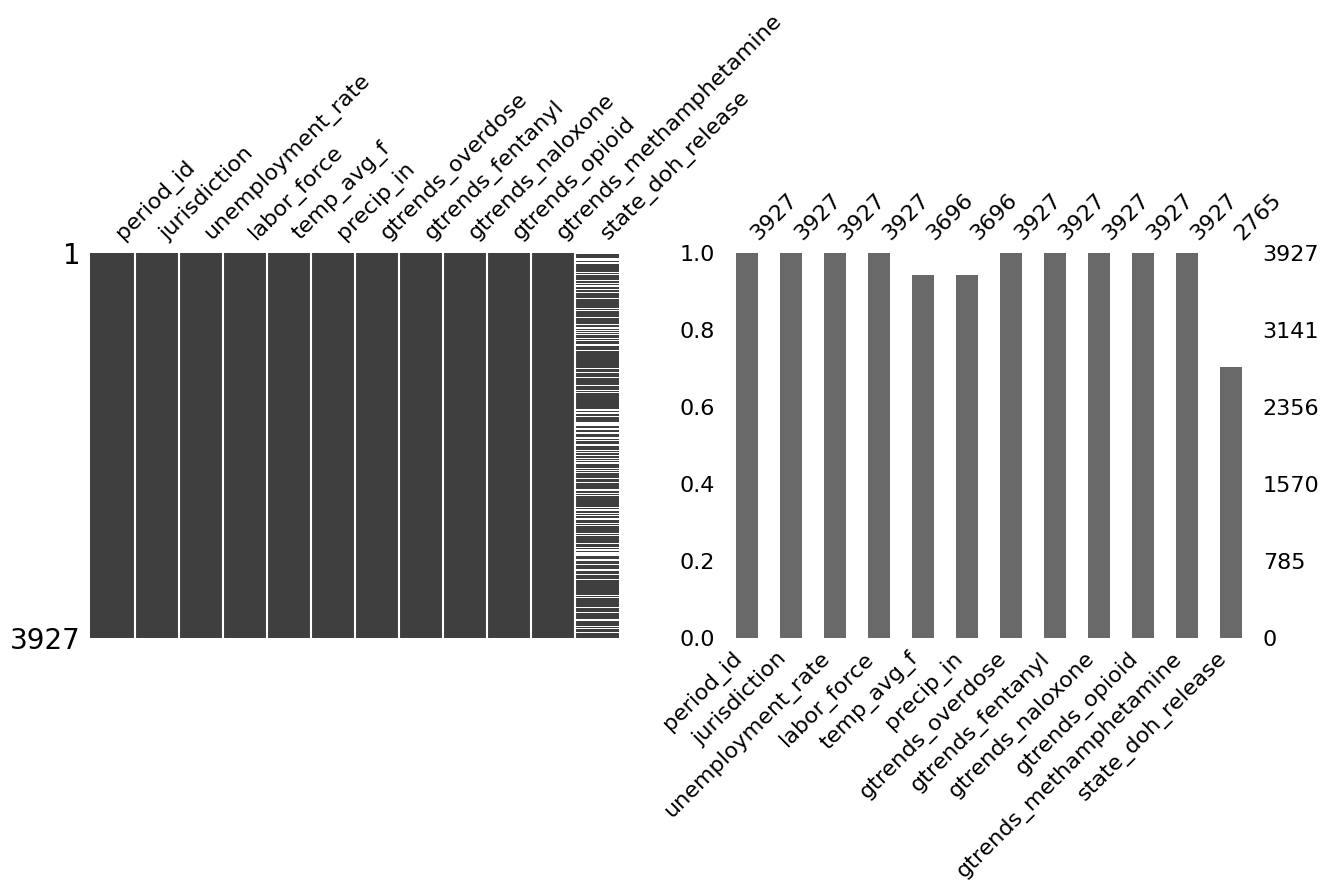

In [ ]:
import missingno

# Examine NA content
fig, axes = plt.subplots(1, 2, figsize = (15, 5))
missingno.matrix(X_raw, ax = axes[0])
missingno.bar(X_raw, ax = axes[1])
plt.show()

We temp and precipitation have the same amount of missing rows. Let's check if these are the same ones.

In [ ]:
# Compare NA rows between temp_avg_f and precip_in
temp_nas = pd.isna(X_raw["temp_avg_f"])
prec_nas = pd.isna(X_raw["precip_in"])
print(f"Are the same datapoints missing from temperature and precipitation features? {np.array_equal(temp_nas, prec_nas)}")

Are the same datapoints missing from temperature and precipitation features? True


Since we're using tree-based models, we don't really need to impute.

## EDA + feature engineering

Some sample resources:
- https://github.com/ashishpatel26/Amazing-Feature-Engineering/blob/master/A%20Short%20Guide%20for%20Feature%20Engineering%20and%20Feature%20Selection.md
- https://www.datacamp.com/tutorial/feature-engineering

Checking distribution of each variable.

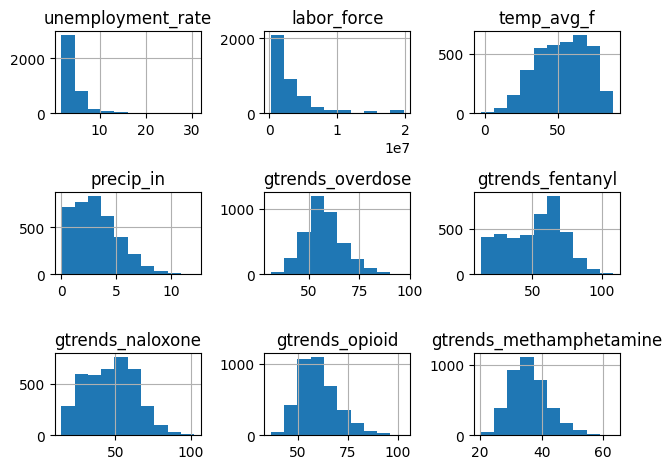

In [ ]:
import seaborn as sns

# Categorical columns
cat_columns = ["period_id", "jurisdiction", "state_doh_release"]

# Continuous columns
cont_columns = X_raw.columns[~X_raw.columns.isin(cat_columns)]
n_cont = len(cont_columns)

# Plot distribution of continuous variables
X_raw[cont_columns].hist()
plt.tight_layout()


We will perform feature engineering to generate informative features based on prior knowledge and also to seamlessly integrate the text and image data with the tabular features.

For tabular features:
- `weather_extremity = temp_avg_f * precip_in`

In [ ]:
# Weather extremity
X_raw["weather_extremity"] = X_raw["temp_avg_f"] * X_raw["precip_in"]

# View
X_raw.head(n = 5)

,period_id,jurisdiction,unemployment_rate,labor_force,temp_avg_f,precip_in,gtrends_overdose,gtrends_fentanyl,gtrends_naloxone,gtrends_opioid,gtrends_methamphetamine,state_doh_release,weather_extremity,region
0,OqDkgaDk,AK,4.5,358314.0,NaN,NaN,50.66,63.50,57.20,49.56,36.89,Alaska Department of Health Authorizes Expande...,NaN,AK
1,OqDkgaDk,AL,2.9,2341587.0,43.3,7.66,57.22,71.71,64.61,55.97,41.66,NaN,331.678,AL
2,OqDkgaDk,AR,3.4,1398700.0,36.1,7.58,59.60,74.70,67.30,58.30,43.40,NaN,273.638,AR
3,OqDkgaDk,AZ,3.5,3715794.0,42.1,1.37,56.02,70.22,63.26,54.80,40.80,Arizona Department of Health Services Announce...,57.677,AZ
4,OqDkgaDk,CA,5.1,19611227.0,45.7,4.63,53.64,67.23,60.57,52.47,39.06,California Department of Public Health Launche...,211.591,CA


Each datapoint is currently specified by the `period_id` and `jurisdiction` columns. Let's concatenate the two to get unique IDs for each datapoint, which we can use throughout the rest of the project.

In [ ]:
def create_ids(df):
  """
  Function to create a column of unique IDs using existing columns

  Args:
    df : dataframe with jurisdiction and period_id columns

  Returns:
    df : same dataframe with 1) new ID column on index and
    2) dropped jurisidiction and period_id columns
  """
  df["ID"] = df["jurisdiction"] + "_" + df["period_id"]
  df = df.set_index("ID")
  df = df.drop(columns = ["jurisdiction", "period_id"])

  return df

X_raw = create_ids(X_raw)
y_raw = create_ids(y_raw)

For the text column, let's randomly sample a few of the rows to see what type of keywords seem to show up in the release messages.

In [ ]:
# Random seed
rng = np.random.default_rng(111)

# Row indices where the state_doh_release is nonempty
non_na_rows = np.where(X_raw["state_doh_release"].isna() == False)[0]

# Random sample of 20
random_lines = rng.choice(non_na_rows, size = 10)
random_msgs = X_raw["state_doh_release"].iloc[random_lines].tolist()

# Print
for msg in random_msgs:
  print(msg, "\n")

Washington State Department of Health Warns Public of Counterfeit Pills Containing Fentanyl
Tablets sold as oxycodone, hydrocodone, Adderall, and Xanax continue to be seized in Washington that, on laboratory analysis, contain illicitly manufactured fentanyl. The Drug Enforcement Administration has reported that approximately 50 percent of counterfeit pills tested nationally contain a potentially lethal dose of fentanyl. Residents are urged to obtain medications only from licensed pharmacies and to assume that any pill obtained from a non-pharmacy source may contain fentanyl regardless of its appearance. Naloxone should be available wherever opioid pills, illicit or otherwise, are present. 

Missouri Department of Health and Senior Services Expands Access to Medication for Opioid Use Disorder
The Department announces the addition of approximately 58 new buprenorphine-prescribing clinicians to the Missouri treatment network as a result of the federal removal of the X-waiver requirement a

For text data (`state_doh_release`):
- `text_presence = (state_doh_release != nan)`
- `num_char = # char`
- `num_numeric = # numeric char`
- `stat_mentions = # of mentions of ["percent", "%", "$"]`
- `opioid_mentions = # of opioid drug names`
- `stimulant_mentions = # of stimulant drug names`
- `any_drug_mentions = # of any drug name`

We'll begin with the simpler features that don't require a regex search for specific keywords.

In [ ]:
# Store text column
text = X_raw["state_doh_release"].fillna("").astype(str)

# Text presence
X_raw["text_presence"] = (~X_raw["state_doh_release"].isna()).astype("int")

# Count characters
X_raw["num_char"] = text.apply(lambda text: len(text.replace(" ", "")))

# Count numeric characters
X_raw["num_numeric"] = text.apply(lambda text: sum([char.isnumeric() for char in text]))

For the features counting specific terms, we need to write a custom regex search. We do this below.

In [ ]:
import re

# Count characters related to statistics
stat_terms = ["percent", "%", "$"]
stat_pattern = re.compile(
    "|".join(re.escape(term) for term in stat_terms),
    flags=re.IGNORECASE
)
X_raw["stat_mentions"] = text.str.count(stat_pattern)

# Lists of opioid drugs, stimulants, and other drugs present in data
# Opioid drug names actually present in state_doh_release
opioid_terms = [
    "opioid",
    "n-pyrrolidino-protonitazene",
    "isotonitazene",
    "buprenorphine",
    "hydrocodone",
    "oxycodone",
    "methadone",
    "fentanyl",
    "nitazene",
]

# Stimulant drug names actually present in state_doh_release
stimulant_terms = [
    "stimulant",
    "methamphetamine",
    "adderall",
    "cocaine",
]

# Other drug / medication terms actually present in state_doh_release
other_drug_terms = [
    "benzodiazepine",
    "naltrexone",
    "naloxone",
    "xylazine",
    "narcan",
    "xanax",
]

# Combine into general drug term list
any_drug_terms = (opioid_terms + stimulant_terms + other_drug_terms)

# Construct regex pattern
def make_nonoverlap_pattern(terms):
    """
    Builds a compiled regex for non-overlapping term counts.

    Longest-first sorting prevents shorter terms from being counted inside
    longer terms, e.g. "nitazene" inside "isotonitazene" or
    "protonitazene" inside "n-pyrrolidino-protonitazene".

    The boundary logic prevents matching terms inside unrelated words.
    """
    terms = sorted(
        set(t.lower().strip() for t in terms if t and t.strip()),
        key=len,
        reverse=True
    )

    escaped_terms = [re.escape(t) for t in terms]

    pattern = (
        r"(?<![A-Za-z0-9])(?:"
        + "|".join(escaped_terms)
        + r")(?![A-Za-z0-9])"
    )

    return re.compile(pattern, flags=re.IGNORECASE)

# Construct patterns for each set of terms
opioid_pattern = make_nonoverlap_pattern(opioid_terms)
stimulant_pattern = make_nonoverlap_pattern(stimulant_terms)
any_drug_pattern = make_nonoverlap_pattern(any_drug_terms)

# Construct drug mention features
X_raw["opioid_mentions"] = text.str.count(opioid_pattern)
X_raw["stimulant_mentions"] = text.str.count(stimulant_pattern)
X_raw["any_drug_mentions"] = text.str.count(any_drug_pattern)


Before constructing any features for the image data, we need to filter out the state border and background, so that we can evaluate our heatmaps solely based on the interior content. We can write a function to mask out the background and light border.

In [ ]:
from scipy.ndimage import binary_erosion

def remove_border(arr, background_value = 0, erosion_pixels = 3, fill_value = np.nan):

    arr = np.asarray(arr)

    # Step 1: state + border are all non-background pixels
    state_mask = arr > background_value

    # Step 2: erode inward to remove border
    interior_mask = binary_erosion(
        state_mask,
        iterations = erosion_pixels
    )

    # Step 3: preserve original heatmap values
    cleaned = arr.astype(float).copy()

    # Step 4: remove background and border
    cleaned[~interior_mask] = fill_value

    return cleaned

# Apply to current images
cleaned_imgs = np.array([remove_border(img) for img in imgs])

For image data:
- `mean_intensity`
- `std_intensity`
- `max_intensity`
- `num_hotspots`

lowkirk figure out later.

In [ ]:
from skimage.feature import peak_local_max

# Restructure file names to match with tabular data IDs
im_names = [name.replace(".png", "") for name in im_names]

# Store simple features
im_means = np.array([np.nansum(arr) / np.sum(arr != np.nan) for arr in cleaned_imgs])
im_stds = np.array([np.nanstd(arr) for arr in cleaned_imgs])
im_maxes = np.array([np.nanmax(arr) for arr in cleaned_imgs])

# Function to find local maxima

# Store num_hotspots



# Construct dataframe


# Join with tabular data

In [ ]:
from skimage.feature import peak_local_max

# Test out the peak local max
arr = cleaned_imgs[12]
mask = ~np.isnan(arr)
maxes = peak_local_max(arr, min_distance = 38)

maxes

array([], shape=(0, 2), dtype=int64)

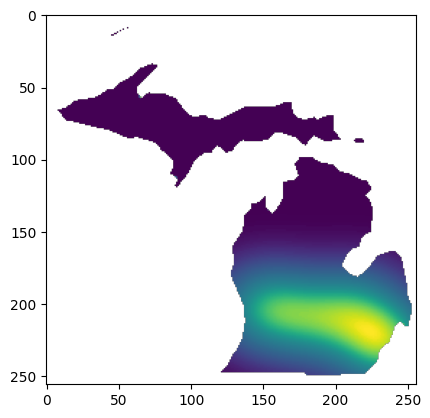

In [ ]:
plt.imshow(arr)

We have a good amount of features so far. Let's take a deeper look. Things we could try:
- Correlation with target variable
- Statistical tests?
- Dimensionality reduction?
- Train basic RF model and rank by importance?
-

Make sure to convert all categorical features to "categorical" in pandas, so that XGBoost and LightGBM are able to natively handle when building trees.***

## Training setup

Let's filter out all the irrevelant overdose categories, then split our target variable into 3 dataframes, each containing the category we're interested in.

In [ ]:
# Print all categories
print(f"Overdose categories in raw data : {y_raw["overdose_category"].unique()} \n")

# Filter to categories of interest
overdose_cats = ["all_drugs", "all_opioids", "all_stimulants"]
y_filtered =  y_raw.loc[y_raw["overdose_category"].isin(overdose_cats)]

# Split categories
y_all_drugs = y_filtered.loc[y_filtered["overdose_category"] == "all_drugs"]
y_all_opioids = y_filtered.loc[y_filtered["overdose_category"] == "all_opioids"]
y_all_stims = y_filtered.loc[y_filtered["overdose_category"] == "all_stimulants"]

# Check dimensions to make sure they match
print(f"# of datapoints in feature datafame : {X_raw.shape[0]}")
print(f"# of targets for all drugs          : {y_all_drugs.shape[0]}")
print(f"# of targets for all opioids        : {y_all_opioids.shape[0]}")
print(f"# of targets for all stimulants     : {y_all_stims.shape[0]}")

Overdose categories in raw data : ['all_drugs' 'all_opioids' 'all_stimulants' 'heroin' 'fentanyl' 'cocaine'
 'methamphetamine' 'benzodiazepine'] 

# of datapoints in feature datafame : 3927
# of targets for all drugs          : 3927
# of targets for all opioids        : 3927
# of targets for all stimulants     : 3927


Eventually, we want 3 separate models for each training target. Each model will use MAE as the score metric. We will implement 5-fold CV for each model to train the hyperparameters.

We will train 3 different models (XGBoost, LightGBM, CatBoost) for each of the 3 prediction targets. Then we will choose 1 best model for each prediction target to be part of the final model.

Hyperparameter tuning objective for XGBoost regressor.

In [ ]:
!pip install optuna
import optuna
import xgboost as xgb
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
import scipy.stats as stats

def make_xgb_objective(X_train, y_train, num_folds):
    """
    Constructs an objective function using specified data to pass to Optuna study
    """
    y_arr = np.asarray(y_train)

    def xgb_objective(trial):
        """
        XGBoost classifier objective function for Optuna. Native Optuna does not support correct early stopping with k-fold CV.
        It requires that we define a fixed validation set used to eavluate early stopping for ALL folds. So, this is a
        workaround that allows each fold to use its corresponding validation set for early stopping.

        Args:
            trial : Parameter for optuna optimize function

        Returns:
            score : Mean MAE across all k folds
        """
        # Define the hyperparameter search space
        params = {
            # Fixed
            "n_estimators": 5000,
            "early_stopping_rounds": 50,
            "random_state": 111,
            "enable_categorical": True, # native handling

            # Tunable
            "learning_rate": trial.suggest_float("learning_rate", 0.001, 0.1, log = True),
            "subsample": trial.suggest_float("subsample", 0.5, 1, step = 0.1),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1, step = 0.1),
            "max_depth": trial.suggest_int("max_depth", 2, 10, step = 1),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 7, step = 2),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 100, log = True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 100, log = True),

            # Eval (use MAE)
            "objective": "reg:absoluteerror",
            "eval_metric": "mae"
        }


        # Initialize k-fold CV splitter
        cv = KFold(
            n_splits = num_folds,
            shuffle = True,
            random_state = 111
        )

        # Store MAE across folds
        scores = []

        # Manual loop for each fold
        for train_idx, val_idx in cv.split(X_train, y_train):

            # Load the train/val sets for the current fold
            X_train_curr = X_train.iloc[train_idx]
            y_train_curr = y_train.iloc[train_idx]
            X_val_curr = X_train.iloc[val_idx]
            y_val_curr = y_train.iloc[val_idx]

            # Initialize XGB classifier model with params
            model = xgb.XGBRegressor(**params)

            # Train the model and predict on current validation set
            model.fit(X_train_curr, y_train_curr, eval_set = [(X_val_curr, y_val_curr)])
            y_pred = model.predict(X_val_curr)

            # Calculate MAE for current fold
            fold_score = mean_absolute_error(y_val_curr, y_pred)
            scores.append(fold_score)

        # Calculate mean MAE across folds
        score = np.mean(scores)

        return score

    return xgb_objective

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 7.4 MB/s eta 0:00:00


Hyperparameter tuning objective for LightGBM regressor.

In [ ]:
import lightgbm as lgb
from lightgbm import early_stopping

def make_lgb_objective(X_train, y_train, num_folds):
    """
    Constructs an objective function using specified data to pass to Optuna study
    """
    y_arr = np.asarray(y_train)

    def lgb_objective(trial):
        """
        LightGBM regressor objective function for Optuna. Native Optuna does not support correct early stopping with k-fold CV.
        It requires that we define a fixed validation set used to eavluate early stopping for ALL folds. So, this is a
        workaround that allows each fold to use its corresponding validation set for early stopping.

        Args:
            trial : Parameter for optuna optimize function

        Returns:
            score : Mean MAE across all k folds
        """
        # Define the hyperparameter search space
        params = {
            # Fixed
            "n_estimators": 5000,
            "random_state": 111,
            "bagging_freq": 1,

            # Tunable
            "num_leaves": trial.suggest_int("num_leaves", 31, 1023, log = True),
            "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 10, 150),
            "learning_rate": trial.suggest_float("learning_rate", 0.001, 0.1, log = True),
            "subsample": trial.suggest_float("subsample", 0.5, 1, step = 0.1),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1, step = 0.1),
            "max_depth": trial.suggest_int("max_depth", 6, 10, step = 1),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 7, step = 2),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 100, log = True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 100, log = True),

            # Eval (use MAE)
            "objective": "reg:absoluteerror",
            "eval_metric": "mae"
        }


        # Initialize k-fold CV splitter
        cv = KFold(
            n_splits = num_folds,
            shuffle = True,
            random_state = 111
        )

        # Store MAE across folds
        scores = []

        # Manual loop for each fold
        for train_idx, val_idx in cv.split(X_train, y_train):

            # Load the train/val sets for the current fold
            X_train_curr = X_train.iloc[train_idx]
            y_train_curr = y_train.iloc[train_idx]
            X_val_curr = X_train.iloc[val_idx]
            y_val_curr = y_train.iloc[val_idx]

            # Initialize XGB classifier model with params
            model = lgb.LGBMRegressor(**params)

            # Train the model and predict on current val set w/ early stopping
            model.fit(
                X_train_curr,
                y_train_curr,
                eval_set = [(X_val_curr, y_val_curr)],
                callbacks = [early_stopping(stopping_rounds = 50)] # early stopping
                )
            y_pred = model.predict(X_val_curr)

            # Calculate MAE for current fold
            fold_score = mean_absolute_error(y_val_curr, y_pred)
            scores.append(fold_score)

        # Calculate mean MAE across folds
        score = np.mean(scores)

        return score

    return lgb_objective

Hyperparameter tuning objective for CatBoost regressor.

In [ ]:
!pip install catboost
import catboost as cb

def make_cb_objective(X_train, y_train, num_folds):
    """
    Constructs an objective function using specified data to pass to Optuna study
    """
    y_arr = np.asarray(y_train)

    def cb_objective(trial):
        """
        CatBoost regressor objective function for Optuna. Native Optuna does not support correct early stopping with k-fold CV.
        It requires that we define a fixed validation set used to eavluate early stopping for ALL folds. So, this is a
        workaround that allows each fold to use its corresponding validation set for early stopping.

        Args:
            trial : Parameter for optuna optimize function

        Returns:
            score : Mean MAE across all k folds
        """
        # Define the hyperparameter search space
        params = {
          # Fixed
          "n_estimators": 5000,
          "random_state": 111,
          "bagging_freq": 1,

          # Tunable ADJUST FOR CATBOOST
          "num_leaves": trial.suggest_int("num_leaves", 31, 1023, log = True),
          "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 10, 150),
          "learning_rate": trial.suggest_float("learning_rate", 0.001, 0.1, log = True),
          "subsample": trial.suggest_float("subsample", 0.5, 1, step = 0.1),
          "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1, step = 0.1),
          "max_depth": trial.suggest_int("max_depth", 6, 10, step = 1),
          "min_child_weight": trial.suggest_int("min_child_weight", 1, 7, step = 2),
          "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 100, log = True),
          "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 100, log = True),

          # Eval (use MAE)
          "objective": "reg:absoluteerror",
          "eval_metric": "mae"
        }

        # Initialize k-fold CV splitter
        cv = KFold(
          n_splits = num_folds,
          shuffle = True,
          random_state = 111
        )

        # Store MAE across folds
        scores = []

        # Manual loop for each fold
        for train_idx, val_idx in cv.split(X_train, y_train):

          # Load the train/val sets for the current fold
          X_train_curr = X_train.iloc[train_idx]
          y_train_curr = y_train.iloc[train_idx]
          X_val_curr = X_train.iloc[val_idx]
          y_val_curr = y_train.iloc[val_idx]

          # Initialize XGB classifier model with params
          model = cb.CatBoostRegressor(**params)

          # Train the model and predict on current val set w/ early stopping
          model.fit(
              X_train_curr,
              y_train_curr,
              eval_set = [(X_val_curr, y_val_curr)],
              callbacks = [early_stopping(stopping_rounds = 50)] # early stopping
              )
          y_pred = model.predict(X_val_curr)

          # Calculate MAE for current fold
          fold_score = mean_absolute_error(y_val_curr, y_pred)
          scores.append(fold_score)

        # Calculate mean MAE across folds
        score = np.mean(scores)

        return score

    return cb_objective

## Tuning and model selection

Define function to tune all 3 model types and output the tuned hyparameters of the best-performing model.

In [ ]:
def find_best_regressor(X_train, y_train, num_folds):
  """
  Function to find and report the best regressor out of LGB, XGB, CB
  for a given training set

  Args:
    X_train : Features
    y_train : Prediction target
    num_folds : # folds for CV during hyperparameter tuning

  Returns:
    best_model : name of best model type
    best_mean_MAE : best score (mean MAE across k folds)
    best_params : best parameters winning model
  """

  # Create median pruner
  median_pruner = optuna.pruners.MedianPruner(
      n_startup_trials = 10, n_warmup_steps = 30, interval_steps = 10
  )

  # Initialize studies
  xgb_study = optuna.create_study(direction = "minimize", pruner = median_pruner)
  lgb_study = optuna.create_study(direction = "minimize", pruner = median_pruner)
  cb_study = optuna.create_study(direction = "minimize", pruner = median_pruner)

  # Initialize objectives
  xgb_objective = make_xgb_objective(X_train, y_train, num_folds)
  lgb_objective = make_lgb_objective(X_train, y_train, num_folds)
  cb_objective = make_cb_objective(X_train, y_train, num_folds)

  # Run studies
  xgb_study.optimize(xgb_objective, n_trials = 150)
  lgb_study.optimize(lgb_objective, n_trials = 150)
  cb_study.optimize(cb_objective, n_trials = 150)

  # Store completed studies
  model_names = ["XGBoost", "LightGBM", "CatBoost"]
  completed_studies = [xgb_study, lgb_study, cb_study]
  mean_scores = [study.best_value for study in completed_studies]

  # Find best MAE and return those params
  best_idx = np.argmax(mean_scores)
  best_model = model_names[best_idx]
  best_mean_MAE = mean_scores[best_idx]
  best_params = completed_studies[best_idx].best_params

  return best_model, best_mean_MAE, best_params

Now, we can run this model selector on each of our three objectives.

In [ ]:
# Load training data
X_train = X_raw

# Set 10-fold CV
num_folds = 10

# Run experiments to find optimal regressor
drug_results = find_best_regressor(X_train, y_all_drugs)
opioid_results = find_best_regressor(X_train, y_all_opioids)
stim_results = find_best_regressor(X_train, y_all_stims)

Now, we can view the optimal models.

# Retraining with optimal hyperparameters

Retrain each model with the optimal hyperparameters.

## Predict on new data

Before doing this, wrap all the feature engineering steps into a sklearn pipeline for ease.

Load the example submission file and rewrite to match the given IDs. Then, we want to bind the original submission file with our predictions.

Finally, we'll write to CSV.